# Question 1

In [ ]:
import cv2, numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
img = cv2.imread("/content/sample_data/emma.jpg")
outdir = "q1_outputs"; os.makedirs(outdir, exist_ok=True)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

lut = np.zeros(256, np.uint8)

for r in range(0, 50):
    lut[r] = r

m1 = (255-100)/(150-50)
for r in range(50, 150):
    lut[r] = np.clip(int(round(100 + m1*(r-50))), 0, 255)

m2 = (255-160)/(255-150)
for r in range(150, 256):
    lut[r] = np.clip(int(round(160 + m2*(r-150))), 0, 255)

lut[50]  = 100
lut[150] = 160

out = cv2.LUT(gray, lut)

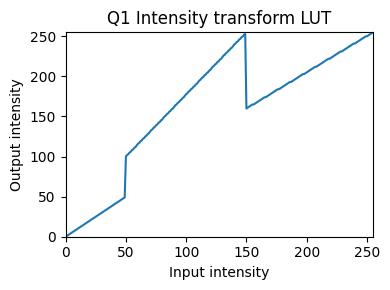

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(np.arange(256), lut)
plt.title("Q1 Intensity transform LUT")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.xlim(0,255); plt.ylim(0,255)
plt.tight_layout()
plt.savefig("q1_emma_curve.png", dpi=150)
plt.show()

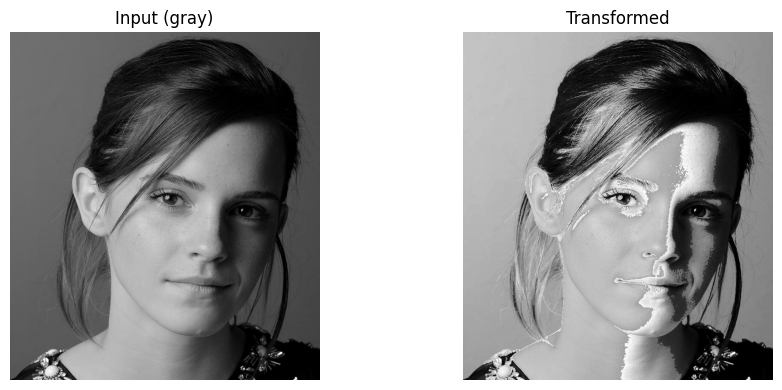

In [ ]:
cv2.imwrite(os.path.join(outdir, "q1_emma_input.png"), gray)
cv2.imwrite(os.path.join(outdir, "q1_emma_output.png"), out)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(gray, cmap="gray"); plt.title("Input (gray)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(out, cmap="gray"); plt.title("Transformed"); plt.axis("off")
plt.tight_layout(); plt.show()

# Question 2

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [ ]:
img_path = "/content/sample_data/brain_proton_density_slice.png"
outdir = "q2_outputs"; os.makedirs(outdir, exist_ok=True)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

t, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

#a)LUT to accentuate white matter
lut_white = np.zeros(256, np.uint8)
for r in range(256):
    if r < t:
        lut_white[r] = int(0.7 * r)
    else:
        lut_white[r] = min(255, int(180 + 2.0 * (r - t)))

#b)LUT to accentuate gray matter
center = int(max(0, t - 20))
sigma = 35.0
gauss = 50 * np.exp(-0.5 * ((np.arange(256) - center) / sigma) ** 2)
lut_gray = np.clip(np.arange(256) + gauss, 0, 255).astype(np.uint8)

wm = cv2.LUT(img, lut_white)
gm = cv2.LUT(img, lut_gray)

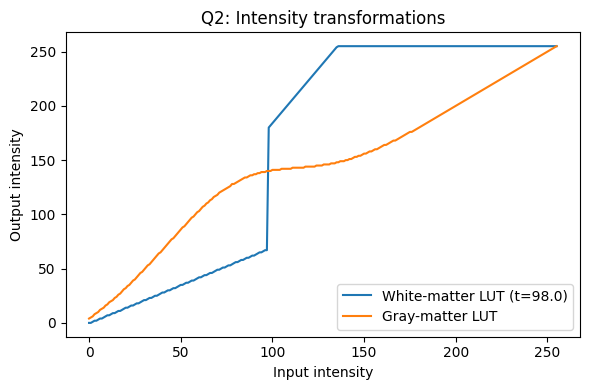

In [ ]:
#Transformation Curve
plt.figure(figsize=(6,4))
plt.plot(np.arange(256), lut_white, label=f"White-matter LUT (t={t})")
plt.plot(np.arange(256), lut_gray,  label="Gray-matter LUT")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.title("Q2: Intensity transformations")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(outdir, "q2_brain_luts.png"), dpi=150)
plt.show()

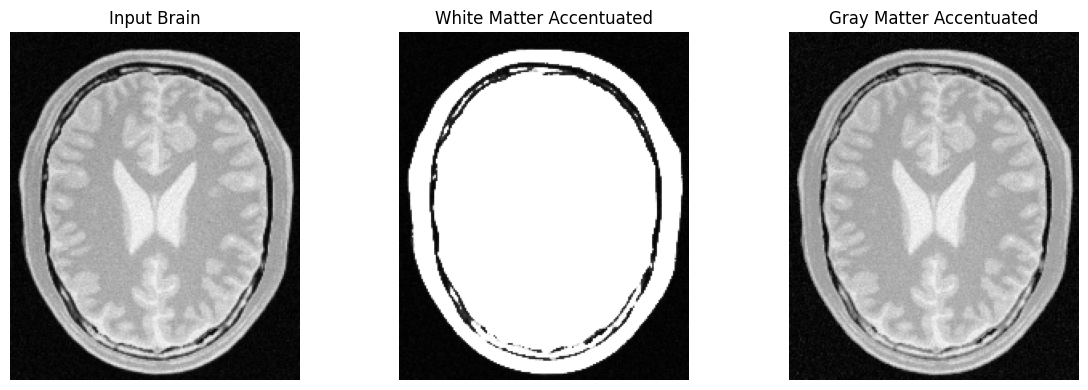

In [ ]:
cv2.imwrite(os.path.join(outdir, "q2_input_brain.png"), img)
cv2.imwrite(os.path.join(outdir, "q2_white_brain.png"), wm)
cv2.imwrite(os.path.join(outdir, "q2_gray_brain.png"),  gm)

#Input/White/Gray Brain Image comparison
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Input Brain"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(wm, cmap="gray"); plt.title("White Matter Accentuated"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(gm, cmap="gray"); plt.title("Gray Matter Accentuated"); plt.axis("off")
plt.tight_layout(); plt.show()

# Question 3

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt

In [ ]:
img_path = "/content/sample_data/highlights_and_shadows.jpg"
outdir = "q3_outputs"; os.makedirs(outdir, exist_ok=True)

In [ ]:
bgr = cv2.imread(img_path)
lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

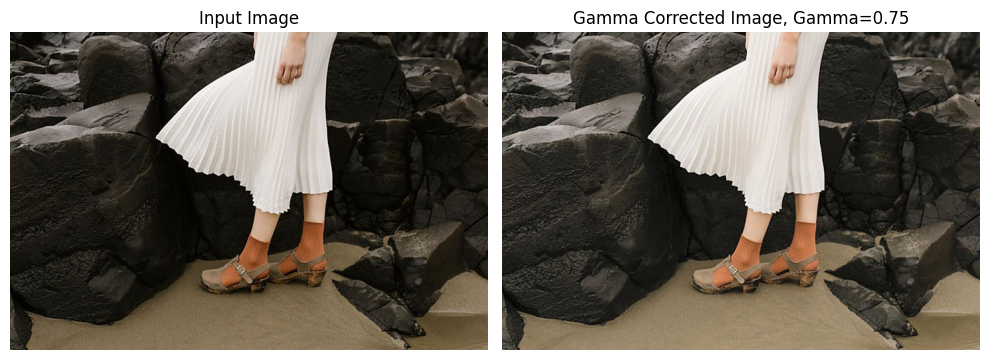

In [ ]:
#(a)Applying gamma correction
gamma = 0.75
L_norm = L.astype(np.float32) / 255.0
L_corr = np.power(L_norm, gamma)
L_corr_u8 = np.clip(L_corr * 255.0, 0, 255).astype(np.uint8)

lab_corr = cv2.merge([L_corr_u8, a, b])
bgr_corr = cv2.cvtColor(lab_corr, cv2.COLOR_LAB2BGR)

cv2.imwrite(os.path.join(outdir,"q3_input.png"), bgr)
cv2.imwrite(os.path.join(outdir,"q3_gamma075.png"), bgr_corr)

#Images of input and corrected images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); plt.title("Input Image"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(bgr_corr, cv2.COLOR_BGR2RGB)); plt.title("Gamma Corrected Image, Gamma=0.75"); plt.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(outdir, "q3_image_comparison.png"), dpi=150)
plt.show()

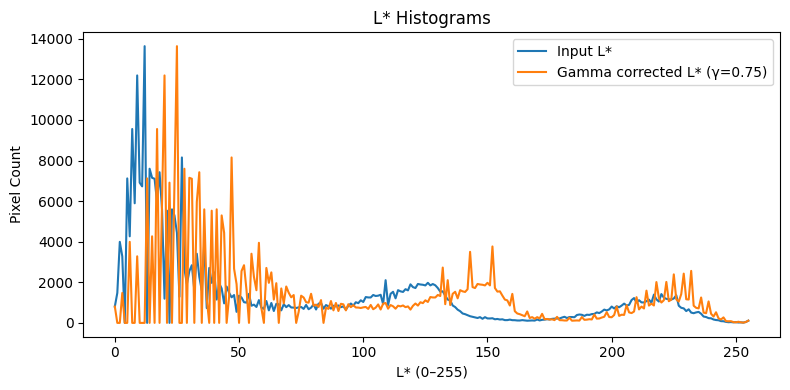

In [ ]:
#(b)Histograms of input and corrected images
hist_orig = cv2.calcHist([L],[0],None,[256],[0,256]).ravel()
hist_corr = cv2.calcHist([L_corr_u8],[0],None,[256],[0,256]).ravel()

plt.figure(figsize=(8,4))
plt.plot(hist_orig, label="Input L*")
plt.plot(hist_corr, label=f"Gamma corrected L* (γ={gamma})")
plt.title("L* Histograms")
plt.xlabel("L* (0–255)")
plt.ylabel("Pixel Count")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q3_histograms.png"), dpi=150)
plt.show()

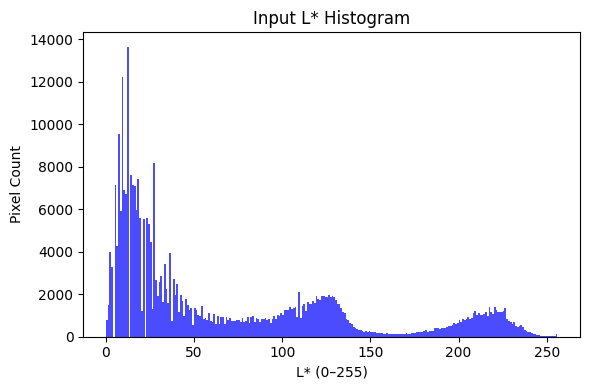

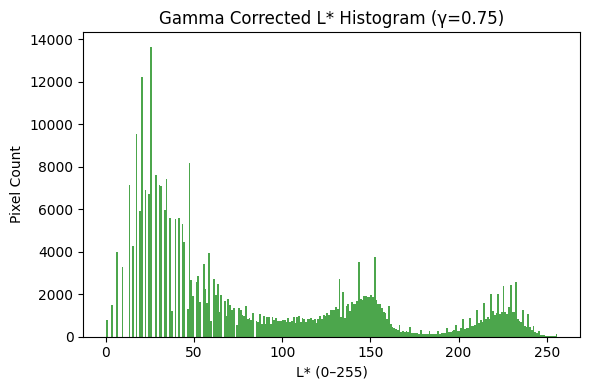

In [ ]:
#If needed to visualize in 2 histograms
#Input L*
plt.figure(figsize=(6,4))
plt.hist(L.ravel(), bins=256, range=(0,256), color="blue", alpha=0.7)
plt.title("Input L* Histogram")
plt.xlabel("L* (0–255)"); plt.ylabel("Pixel Count")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q3_hist_original.png"), dpi=150)
plt.show()

#Gamma corrected L*
plt.figure(figsize=(6,4))
plt.hist(L_corr_u8.ravel(), bins=256, range=(0,256), color="green", alpha=0.7)
plt.title(f"Gamma Corrected L* Histogram (γ={gamma})")
plt.xlabel("L* (0–255)"); plt.ylabel("Pixel Count")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q3_hist_corrected.png"), dpi=150)
plt.show()

# Question 4

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [ ]:
img_path = "/content/sample_data/spider.png"
outdir = "q4_outputs"; os.makedirs(outdir, exist_ok=True)

In [ ]:
bgr = cv2.imread(img_path)
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

def vibrance_lut(a, sigma=70.0):
    x = np.arange(256, dtype=np.float32)
    bump = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * sigma * sigma))
    return np.clip(x + bump, 0, 255).astype(np.uint8)

In [ ]:
#a)Splitting image to Hue, Saturation and Value planes
H, S, V = cv2.split(hsv)

cv2.imwrite(os.path.join(outdir, "q4_H.png"), H)
cv2.imwrite(os.path.join(outdir, "q4_S.png"), S)
cv2.imwrite(os.path.join(outdir, "q4_V.png"), V)

True

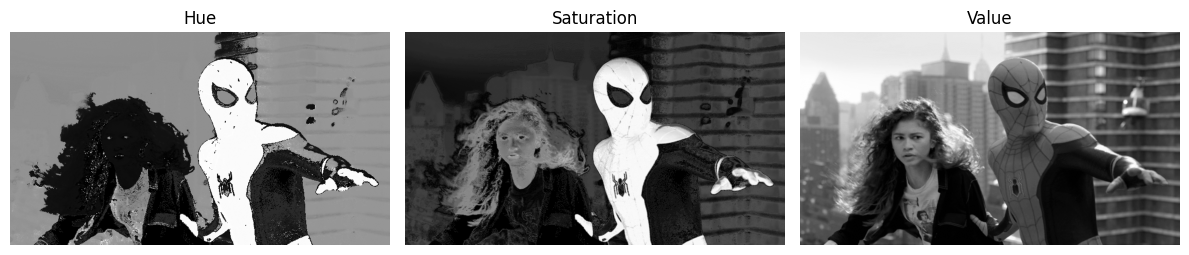

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(H, cmap="gray"); plt.title("Hue"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(S, cmap="gray"); plt.title("Saturation"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(V, cmap="gray"); plt.title("Value"); plt.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
#b)Applying the given intensity transformation to Saturation plane (S)
a = 0.70
lut = vibrance_lut(a, sigma=70.0)
S_enh = cv2.LUT(S, lut)

In [ ]:
#c)Adjusting a with couple of candidate options to pick by mean-saturation lift
candidates = [0.3, 0.5, 0.7, 0.9]
best_a, best_gain = None, -1e9
for a_try in candidates:
    lut_try = vibrance_lut(a_try)
    S_try = cv2.LUT(S, lut_try)
    gain = float(S_try.mean() - S.mean())
    if gain > best_gain:
        best_gain, best_a, S_enh, lut = gain, a_try, S_try, lut_try

print(f"Chosen a = {best_a:.2f} (mean saturation gain = {best_gain:.2f})")

Chosen a = 0.90 (mean saturation gain = 52.79)


In [ ]:
#d)Recombining all the three planes(H, S & V)
a = 0.90
lut = vibrance_lut(a, sigma=70.0)
S_enh = cv2.LUT(S, lut)

hsv_enh = cv2.merge([H, S_enh, V])
bgr_enh = cv2.cvtColor(hsv_enh, cv2.COLOR_HSV2BGR)

cv2.imwrite(os.path.join(outdir, "q4_input.png"), bgr)
cv2.imwrite(os.path.join(outdir, "q4_vibrance.png"), bgr_enh)

True

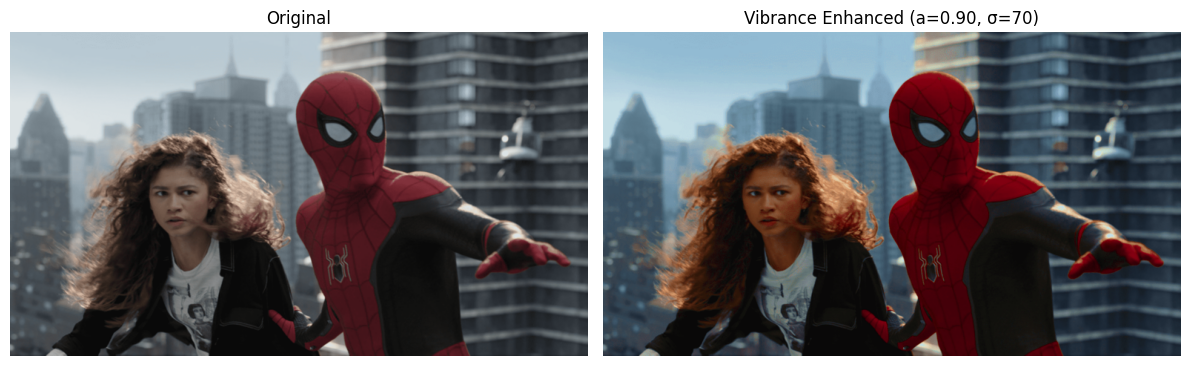

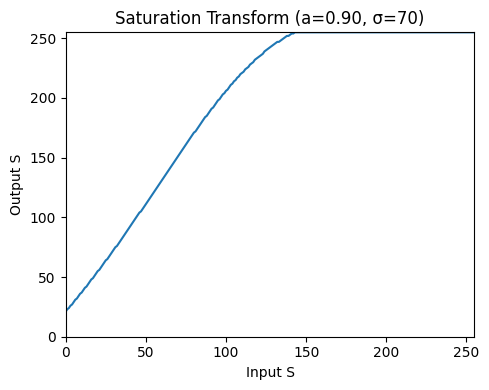

In [ ]:
#e)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(bgr_enh, cv2.COLOR_BGR2RGB)); plt.title(f"Vibrance Enhanced (a={a:.2f}, σ=70)"); plt.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(outdir, "q4_image_comparison.png"), dpi=150)
plt.show()

x = np.arange(256)
plt.figure(figsize=(5,4))
plt.plot(x, lut)
plt.title(f"Saturation Transform (a={a:.2f}, σ=70)")
plt.xlabel("Input S"); plt.ylabel("Output S")
plt.xlim(0,255); plt.ylim(0,255)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q4_lut_curve.png"), dpi=150)
plt.show()

# Question 5

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [ ]:
img_path = "/content/sample_data/jeniffer.jpg"
outdir   = "q5_outputs"; os.makedirs(outdir, exist_ok=True)

In [ ]:
bgr = cv2.imread(img_path)

In [ ]:
#a)Splitting image to Hue, Saturation and Value planes
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

cv2.imwrite(os.path.join(outdir, "q5_H.png"), H)
cv2.imwrite(os.path.join(outdir, "q5_S.png"), S)
cv2.imwrite(os.path.join(outdir, "q5_V.png"), V)

True

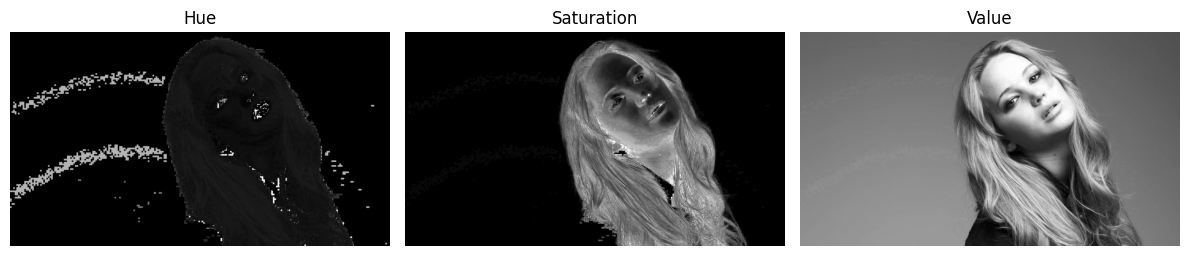

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(H, cmap="gray"); plt.title("Hue"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(S, cmap="gray"); plt.title("Saturation"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(V, cmap="gray"); plt.title("Value"); plt.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
#b)Threshold an appropriate plane to get the foreground mask
_, mask0 = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask0, cv2.MORPH_OPEN,  kernel, iterations=1)
mask = cv2.morphologyEx(mask,  cv2.MORPH_CLOSE, kernel, iterations=2)

num, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
if num > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = np.uint8(labels == largest) * 255

cv2.imwrite(os.path.join(outdir, "q5_mask.png"), mask)

True

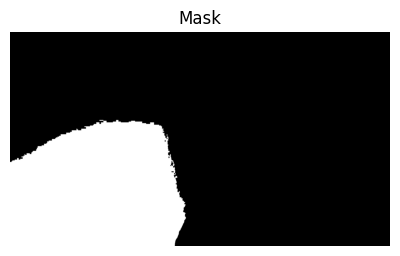

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.tight_layout(); plt.show()

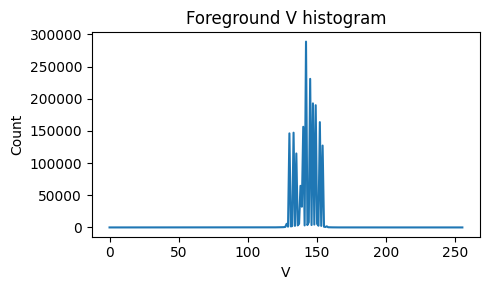

In [ ]:
#c)Extract foreground only and compute its histogram
V_fg = cv2.bitwise_and(V, V, mask=mask)
hist_fg = cv2.calcHist([V_fg], [0], mask, [256], [0,256]).ravel()

plt.figure(figsize=(5,3)); plt.plot(hist_fg); plt.title("Foreground V histogram")
plt.xlabel("V"); plt.ylabel("Count"); plt.tight_layout()
plt.savefig(os.path.join(outdir, "q5_fg_hist.png"), dpi=150); plt.show()

In [ ]:
#d)Cumulative sum of the histogram
cdf = np.cumsum(hist_fg)

cdf_masked = np.ma.masked_equal(cdf, 0)

In [ ]:
#e)Histogram-equalize the foreground
N = cdf_masked.max()
cdf_eq = (cdf_masked - cdf_masked.min()) * 255.0 / (N - cdf_masked.min())
cdf_eq = np.ma.filled(cdf_eq, 0).astype(np.uint8)

V_eq_all = cv2.LUT(V, cdf_eq)
V_fg_eq  = cv2.bitwise_and(V_eq_all, V_eq_all, mask=mask)

In [ ]:
#f)Extract the background and add with the histogram equalized foreground
bg_mask = cv2.bitwise_not(mask)
V_bg = cv2.bitwise_and(V, V, mask=bg_mask)
V_final = cv2.add(V_fg_eq, V_bg)

hsv_out = cv2.merge([H, S, V_final])
bgr_out = cv2.cvtColor(hsv_out, cv2.COLOR_HSV2BGR)

cv2.imwrite(os.path.join(outdir, "q5_input.png"), bgr)
cv2.imwrite(os.path.join(outdir, "q5_result.png"), bgr_out)

True

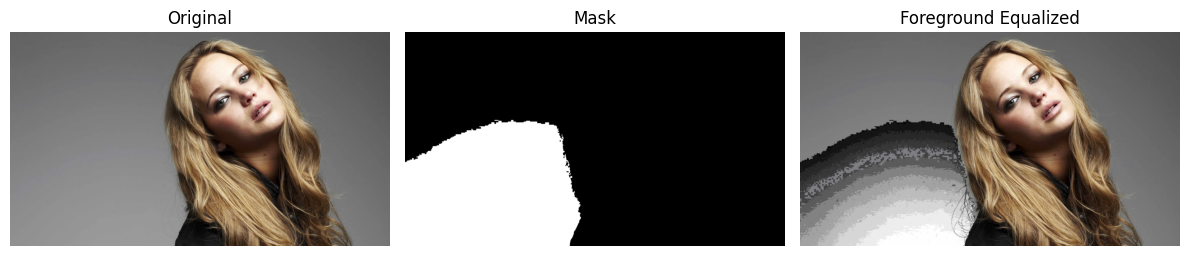

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(bgr_out, cv2.COLOR_BGR2RGB)); plt.title("Foreground Equalized"); plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q5_triptych.png"), dpi=150); plt.show()

# Question 6

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [ ]:
img_path = "/content/sample_data/einstein.png"
outdir = "q6_outputs"; os.makedirs(outdir, exist_ok=True)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

In [ ]:
#Sobel Kernels
Kx = np.array([[ 1, 0,-1],
               [ 2, 0,-2],
               [ 1, 0,-1]], dtype=np.float32)
Ky = Kx.T

In [ ]:
#a)Using existing filter2D to Sobel filter the image
gx_a = cv2.filter2D(img, cv2.CV_32F, Kx)
gy_a = cv2.filter2D(img, cv2.CV_32F, Ky)

mag_a = cv2.magnitude(gx_a, gy_a)
mag_a_u8 = cv2.convertScaleAbs(mag_a)

cv2.imwrite(os.path.join(outdir, "q6a_gx.png"), cv2.convertScaleAbs(gx_a))
cv2.imwrite(os.path.join(outdir, "q6a_gy.png"), cv2.convertScaleAbs(gy_a))
cv2.imwrite(os.path.join(outdir, "q6a_mag.png"), mag_a_u8)

True

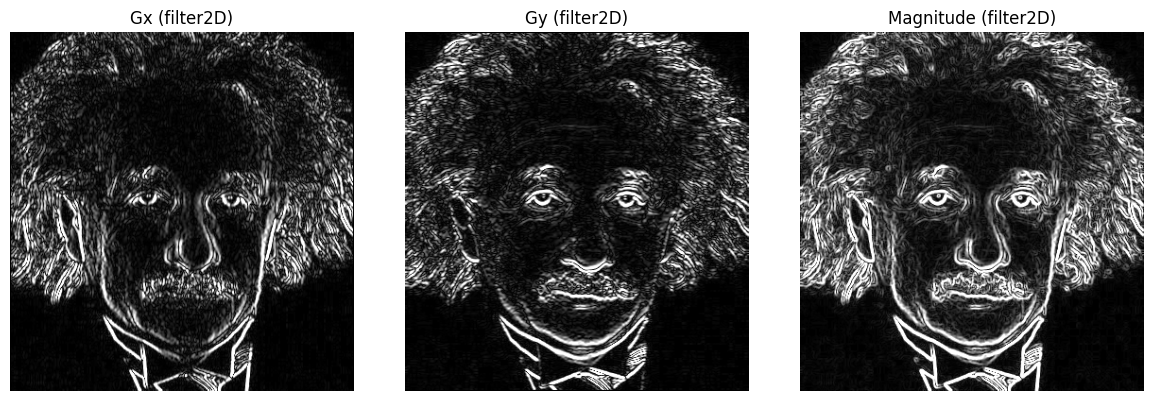

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.convertScaleAbs(gx_a), cmap="gray"); plt.title("Gx (filter2D)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(cv2.convertScaleAbs(gy_a), cmap="gray"); plt.title("Gy (filter2D)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_a_u8, cmap="gray"); plt.title("Magnitude (filter2D)"); plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#b)Code for Sobel filtering the image manually
def conv2(src, kernel):
    kh, kw = kernel.shape
    ph, pw = kh//2, kw//2
    src_p = cv2.copyMakeBorder(src, ph, ph, pw, pw, cv2.BORDER_REFLECT)
    out = np.zeros_like(src, dtype=np.float32)
    k = np.flipud(np.fliplr(kernel)).astype(np.float32)
    for y in range(out.shape[0]):
        for x in range(out.shape[1]):
            roi = src_p[y:y+kh, x:x+kw].astype(np.float32)
            out[y, x] = np.sum(roi * k)
    return out

gx_b = conv2(img, Kx)
gy_b = conv2(img, Ky)
mag_b = cv2.magnitude(gx_b, gy_b)
mag_b_u8 = cv2.convertScaleAbs(mag_b)

cv2.imwrite(os.path.join(outdir, "q6b_mag_manual.png"), mag_b_u8)

True

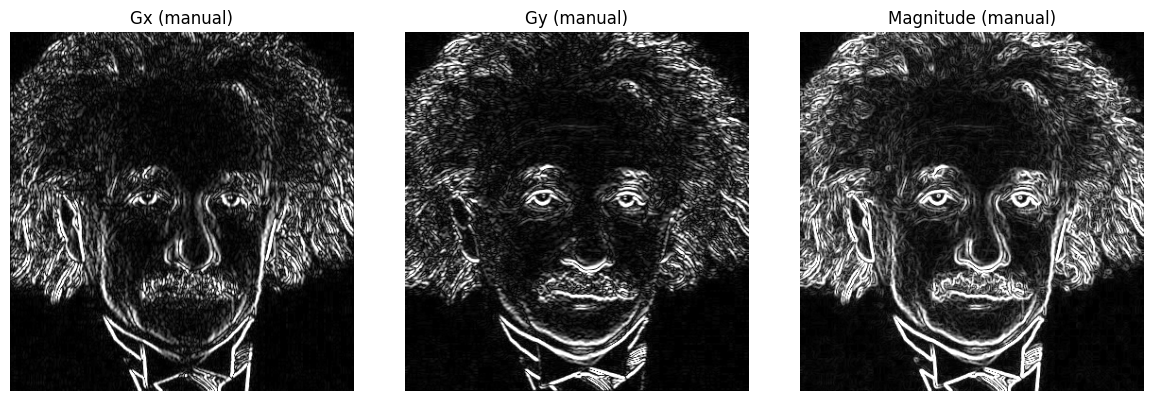

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.convertScaleAbs(gx_b), cmap="gray"); plt.title("Gx (manual)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(cv2.convertScaleAbs(gy_b), cmap="gray"); plt.title("Gy (manual)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_b_u8, cmap="gray"); plt.title("Magnitude (manual)"); plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#c)Sobel using separability
col = np.array([[1],[2],[1]], dtype=np.float32)
row = np.array([[1,0,-1]], dtype=np.float32)

gx_c = cv2.sepFilter2D(img, cv2.CV_32F, row, col)
gy_c = cv2.sepFilter2D(img, cv2.CV_32F, col, row)

mag_c = cv2.magnitude(gx_c, gy_c)
mag_c_u8 = cv2.convertScaleAbs(mag_c)

cv2.imwrite(os.path.join(outdir, "q6c_mag_separable.png"), mag_c_u8)

True

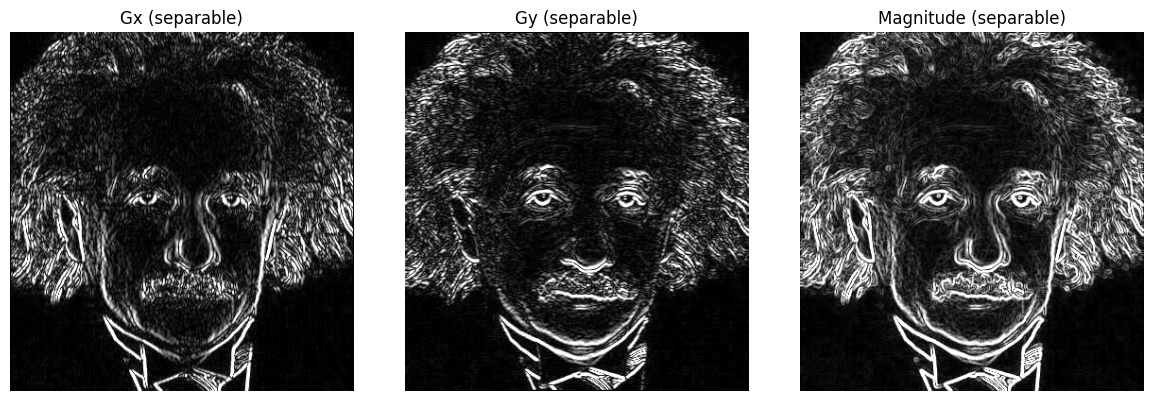

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.convertScaleAbs(gx_c), cmap="gray"); plt.title("Gx (separable)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(cv2.convertScaleAbs(gy_c), cmap="gray"); plt.title("Gy (separable)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_c_u8, cmap="gray"); plt.title("Magnitude (separable)"); plt.axis("off")
plt.tight_layout()
plt.show()

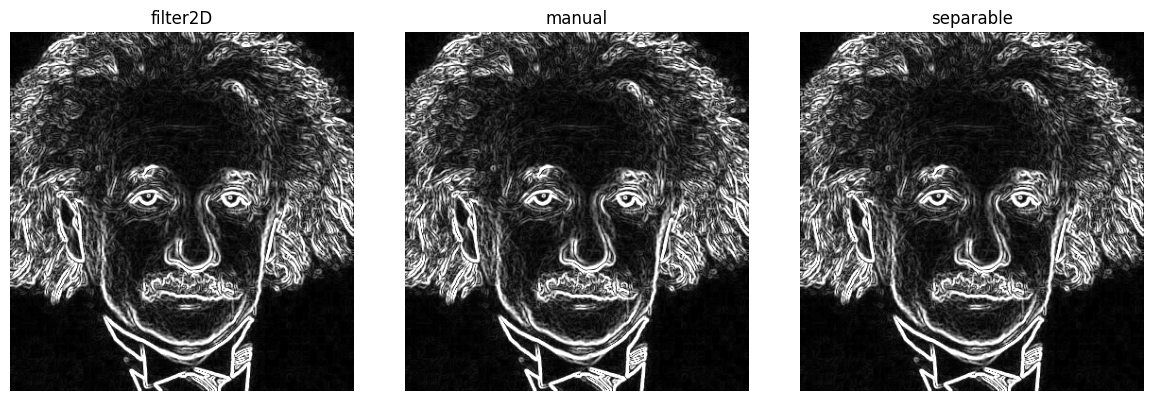

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(mag_a_u8, cmap="gray"); plt.title("filter2D");   plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mag_b_u8, cmap="gray"); plt.title("manual");     plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_c_u8, cmap="gray"); plt.title("separable");  plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q6_comparison.png"), dpi=150)
plt.show()